In [1]:
# https://www.marktechpost.com/2026/04/27/how-to-build-a-lightweight-vision-language-action-inspired-embodied-agent-with-latent-world-modeling-and-model-predictive-control/

In [2]:
import random, numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Tuple, Dict, List
from torch.utils.data import Dataset, DataLoader
from torch import device
from einops import reduce
from einops.layers.torch import Rearrange

try:
   from tqdm.auto import tqdm
except Exception:
   def tqdm(x, **kwargs): return x


SEED = 7
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



/home/server/miniconda3/envs/dev_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


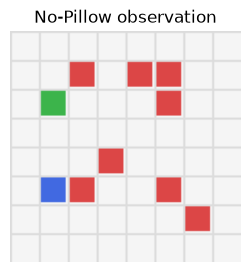

In [3]:
@dataclass
class WorldConfig:
    grid_size: int=8
    cell_px: int=14
    max_steps: int=45
    n_obstacles: int=8
    spawn_margin: int=1

class GridWorld:
    ACTION_NAMES = { 0: "UP", 1: "DOWN", 2: "LEFT", 3:"RIGHT" }
    ACTIONS = { 0: (0, -1), 1: (0, 1), 2: (-1, 0), 3: (1, 0) }

    def __init__(self, cfg: WorldConfig):
        self.cfg = cfg
        self.reset()

    def reset(self) -> Dict:
        g = self.cfg.grid_size
        self.steps = 0

        def sample_empty(exclude=set()):
            while True:
                x = random.randint(self.cfg.spawn_margin, g-1-self.cfg.spawn_margin)
                y = random.randint(self.cfg.spawn_margin, g-1-self.cfg.spawn_margin)
                if (x,y) not in exclude: 
                    return (x,y)
        self.obstacles = set()
        ax, ay = sample_empty()
        gx, gy = sample_empty(exclude=[(ax, ay)])
        used = {(ax,ay),(gx,gy)}
        for _ in range(self.cfg.n_obstacles):
            ox, oy = sample_empty(exclude=used)
            self.obstacles.add((ox,oy))
            used.add((ox,oy))
        self.agent = (ax,ay)
        self.goal = (gx,gy)
        return {"image": self._render_u8()}

    def _in_bounds(self, x, y):
       return 0 <= x < self.cfg.grid_size and 0 <= y < self.cfg.grid_size


    def _dist_to_goal(self, pos: Tuple[int,int]) -> float:
        x,y = pos; gx,gy = self.goal
        return abs(x-gx)+abs(y-gy)


    def _state_vector(self) -> np.ndarray:
        g = self.cfg.grid_size - 1
        ax, ay = self.agent
        gx, gy = self.goal
        return np.array([ax/g, ay/g, gx/g, gy/g], dtype=np.float32)

    def step(self, action: int):
        self.steps += 1
        dx, dy = self.ACTIONS[int(action)]
        x, y = self.agent
        nx, ny = x+dx, y+dy
        if self._in_bounds(nx, ny) and (nx, ny) not in self.obstacles:
            self.agent = (nx, ny)
        done = (self.agent == self.goal) or (self.steps >= self.cfg.max_steps)
        d_prev = self._dist_to_goal((x,y))
        d_now = self._dist_to_goal(self.agent)
        reward = 0.1*(d_prev - d_now) + (1.0 if self.agent == self.goal else 0.0)
        obs = {"image": self._render_u8()}
        info = {"state": self._state_vector()}
        return obs, float(reward), bool(done), info

    def _render_u8(self) -> np.ndarray:
        g, s = self.cfg.grid_size, self.cfg.cell_px
        H = W = g*s
        bg = np.array([245,245,245], np.uint8)
        gridline = np.array([220,220,220], np.uint8)
        obstacle_c = np.array([220,70,70], np.uint8)
        goal_c = np.array([60,180,75], np.uint8)
        agent_c = np.array([65,105,225], np.uint8)
        img = np.empty((H,W,3), np.uint8); img[...] = bg
        img[::s,:,:] = gridline
        img[:,::s,:] = gridline
        def paint_cell(x,y,color):
            y0,y1 = y*s,(y+1)*s
            x0,x1 = x*s,(x+1)*s
            img[y0+1:y1-1, x0+1:x1-1] = color
        for (ox,oy) in self.obstacles: paint_cell(ox,oy, obstacle_c)
        gx,gy = self.goal; paint_cell(gx,gy, goal_c)
        ax,ay = self.agent; paint_cell(ax,ay, agent_c)
        return img

cfg = WorldConfig()
env = GridWorld(cfg)
plt.figure(figsize=(3,3))
plt.imshow(env.reset()["image"]); plt.axis("off"); plt.title("No-Pillow observation"); plt.show()


def to_tensor_img_u8(img_u8: np.ndarray) -> torch.Tensor:
   return torch.from_numpy(img_u8).permute(2,0,1).float() / 255.0


In [4]:
from typing import Any


class TransitionDataset(Dataset):
    def __init__(self, items) -> None:
        super().__init__()
        self.items = items
    def __len__(self):
        return len(self.items)
    def __getitem__(self, index) -> Any:
        it = self.items[index]
        return {**it, "img": it["img"].float()/255.0, "next_img": it["next_img"].float()/255.0}

def collect_transitions(n_episodes=1000):
    items = []
    env = GridWorld(cfg=cfg)
    for _ in tqdm(range(n_episodes), desc="Collect"):
        obs = env.reset()
        img = torch.from_numpy(obs["image"]).permute(2,0,1).contiguous()
        state = torch.from_numpy(env._state_vector()).float()
        for _ in range(cfg.max_steps):
            action = random.randint(0, 3)
            new_obj, reward, done, info = env.step(action=action)
            next_img = torch.from_numpy(new_obj["image"]).permute(2,0,1).contiguous()
            next_state = torch.from_numpy(info["state"]).float()
            goal = next_state[2:4].clone()
            items.append({
                "img": img,
                "state": state, 
                "action": torch.tensor(action, dtype=torch.long), 
                "next_img": next_img,
                "next_state": next_state, 
                "goal": goal   
            })
            img = next_img
            state = next_state
            if done:
                break
    return items

items = collect_transitions(n_episodes=1000)
print("Transitions: ", len(items))
H, W = items[0]["img"].shape[1], items[0]["img"].shape[2]
dataloader = DataLoader(TransitionDataset(items), batch_size=64, shuffle=True, num_workers=0, drop_last=True)

Collect:   0%|          | 0/1000 [00:00<?, ?it/s]

Collect:   2%|▏         | 24/1000 [00:00<00:04, 227.60it/s]

Collect:   5%|▌         | 50/1000 [00:00<00:03, 243.13it/s]

Collect:   8%|▊         | 80/1000 [00:00<00:03, 264.14it/s]

Collect:  11%|█         | 110/1000 [00:00<00:03, 275.79it/s]

...

Collect:  94%|█████████▎| 936/1000 [00:03<00:00, 219.03it/s]

Collect:  96%|█████████▌| 959/1000 [00:04<00:00, 205.62it/s]

Collect:  98%|█████████▊| 981/1000 [00:04<00:00, 201.68it/s]

Collect: 100%|██████████| 1000/1000 [00:04<00:00, 232.68it/s]

Transitions:  37819


In [5]:
from typing import Any


class Encoder(nn.Module):
    def __init__(self, H, W, zdim=64) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 24, 5, stride=2, padding=2), nn.ReLU(),
            nn.Conv2d(24, 48, 5, stride=2, padding=2), nn.ReLU(),
            nn.Conv2d(48, 64, 3, stride=2, padding=1), nn.ReLU(),
        )
        with torch.no_grad():
            self.feat_shape = tuple(self.net(torch.zeros(1, 3, H, W)).shape[1:])
        self.flatten = Rearrange('b c h w -> b (c h w)')
        self.fc = nn.Linear(int(np.prod(self.feat_shape)), zdim)
    def forward(self, x):
        return self.fc(self.flatten(self.net(x)))

class Decoder(nn.Module):
    def __init__(self, feat_shape, zdim=64):
        super().__init__()
        C, h, w = feat_shape
        
        self.net = nn.Sequential(
            nn.Linear(zdim, C * h * w),
            Rearrange('b (c h w) -> b c h w', c=C, h=h, w=w),
            
            nn.ConvTranspose2d(C, 48, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(48, 24, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(24, 16, 4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 3, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, z):
        return self.net(z)
    

class VLASimLite(nn.Module):
    def __init__(self, H, W, zdim=64, act_dim=5, *args: Any, **kwargs: Any) -> None:
        super().__init__(*args, **kwargs)
        self.enc = Encoder(H, W, zdim)
        self.dec = Decoder(self.enc.feat_shape, zdim)
        self.act_emb = nn.Embedding(act_dim, 16)
        self.goal_net = nn.Sequential(nn.Linear(2,16), nn.ReLU(), nn.Linear(16,16))
        self.dyn = nn.Sequential(
            nn.Linear(zdim+16+16, 128), nn.ReLU(),
            nn.Linear(128, zdim)
        )
        self.state = nn.Sequential(
            nn.Linear(zdim, 64), nn.ReLU(),
            nn.Linear(64, 4),
            nn.Sigmoid()
        )
    def encode(self, img):
        return self.enc(img)

    def predict_next_latent(self, z, a, goal):
        return self.dyn(
            torch.cat([z, self.act_emb(a), self.goal_net(goal)], dim=-1)
        )
    def decode(self, z):
        return self.dec(z)

    def forward(self, img, act, goal):
        z = self.enc(img)
        z_next = self.predict_next_latent(z, act, goal)
        return z_next, self.decode(z_next), self.state(z_next)

In [6]:
model = VLASimLite(H, W, zdim=64, act_dim=5).to(device=device)
opt = torch.optim.Adam(model.parameters(), lr=2e-3)


In [7]:
def train(epochs=30):
    model.train()
    for epoch in range(1, epochs+1):
        losses = []
        for batch in dataloader:
            img = batch["img"].to(device)
            action = batch["action"].to(device)
            next_img = batch["next_img"].to(device)
            next_state = batch["next_state"].to(device)
            goal = batch["goal"].to(device)
            state = batch["state"].to(device)
            z = model.encode(img)
            z_next = model.predict_next_latent(z, action, goal)
            img_pred, st_pred = model.decode(z_next), model.state(z_next)
            loss = F.l1_loss(img_pred, next_img) + 3.0*F.mse_loss(st_pred, next_state) + 3.0*F.mse_loss(model.state(z), state) + 1e-4*z_next.pow(2).mean()
            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 2.0)
            opt.step()
            losses.append(loss.item())
        print("Epoch", epoch, "loss", float(np.mean(losses)))
train(epochs=30)

Epoch 1 loss 0.26280726477251215


Epoch 2 loss 0.19419462233781815


Epoch 3 loss 0.1546192756648791


Epoch 4 loss 0.15166952402914985


Epoch 5 loss 0.14989510921098417


...

Epoch 26 loss 0.14701792972825342


Epoch 27 loss 0.14704775408668033


Epoch 28 loss 0.14696684227151385


Epoch 29 loss 0.14690308247582387


Epoch 30 loss 0.1466615230097609


In [8]:
# Random shooting MPC
@torch.no_grad()
def mpc_action(img, horizon=6, n_candidates=120, action_space=4):
    model.eval()
    # encode the current observation into label
    z = model.encode(img)
    current_state = model.state(z)
    goal = current_state[:,2:4].clamp(0,1)
    # sample random action
    candidates = torch.randint(0, action_space, (n_candidates, horizon), device=device)
    # copy z and goal so all candidates can run in parallel
    z_roll = z.repeat(n_candidates, 1)
    goal_roll = goal.repeat(n_candidates, 1)
    # loop the dynamics
    for t in range(horizon):
        z_roll = model.predict_next_latent(z_roll, candidates[:,t], goal_roll)
    final_state = model.state(z_roll)
    dist = torch.abs(final_state[:,0:2] - final_state[:,2:4]).sum(dim=-1)
    changes = (candidates[:, 1:] != candidates[:, :-1]).float().mean(dim=1)
    score = dist + 0.12*changes
    best = torch.argmin(score)
    return int(candidates[best,0].item())

    

In [9]:
@torch.no_grad()
def predict_next_frame(img_u8, action):
    model.eval()
    img = to_tensor_img_u8(img_u8).unsqueeze(0).to(device)
    z = model.encode(img)
    state = model.state(z)
    goal = state[:, 2:4].clamp(0, 1)
    act = torch.tensor([action], dtype=torch.long, device=device)
    z_next = model.predict_next_latent(z, act, goal)
    pred = model.decode(z_next)[0].cpu().permute(1, 2, 0).numpy()
    return (pred*255.0).clip(0,255).astype(np.uint8)

In [10]:
def run_episode(max_steps=45):
    e = GridWorld(cfg)
    obs = e.reset()
    real, pred, acts, rews = [], [], [], []
    for _ in range(max_steps):
        img = obs["image"]
        real.append(img)
        a = mpc_action(to_tensor_img_u8(img).unsqueeze(0).to(device), horizon=6, n_candidates=120)
        pred.append(predict_next_frame(img, a))
        obs, r, done, info = e.step(a)
        acts.append(a); rews.append(r)
        if done:
            real.append(obs["image"])
            pred.append(pred[-1])
            break
    return real, pred, acts, rews

real, pred, acts, rews = run_episode()
print("Steps:", len(acts), "Return:", round(sum(rews), 3))

Steps: 45 Return: -0.3


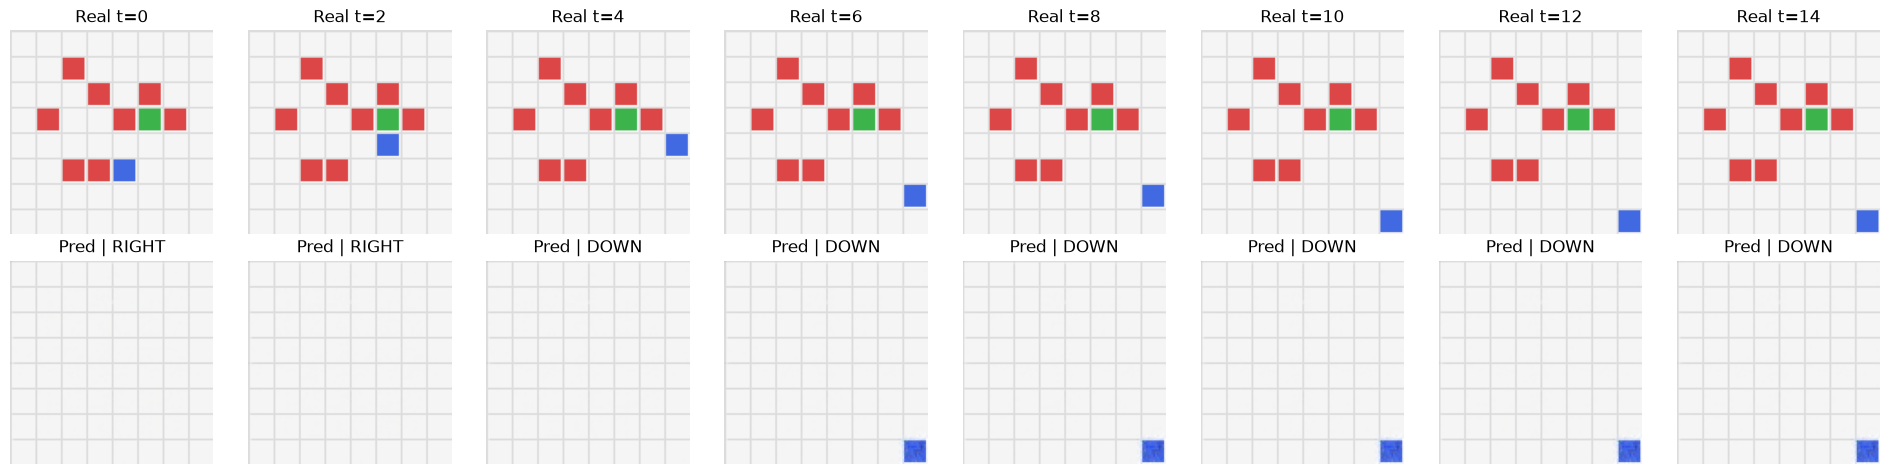

Pipeline OK


In [11]:
def show(real, pred, acts, every=2, panels=8):
    idxs = list(range(0, min(len(acts), every*panels), every))
    n = len(idxs)
    plt.figure(figsize=(2.4*n, 4.8))
    for j,i in enumerate(idxs):
        plt.subplot(2,n,j+1); plt.imshow(real[i]); plt.axis("off"); plt.title(f"Real t={i}")
        plt.subplot(2,n,n+j+1); plt.imshow(pred[i]); plt.axis("off"); plt.title(f"Pred | {GridWorld.ACTION_NAMES[acts[i]]}")
    plt.tight_layout(); plt.show()

show(real, pred, acts, every=2, panels=8)
print("Pipeline OK")

In [12]:
def evaluate(policy, n_episodes=50, max_steps=45):
    succ, rets, lens = 0, [], []
    for _ in tqdm(range(n_episodes), desc=policy.__name__, leave=False):
        e = GridWorld(cfg); obs = e.reset(); total = 0.0
        for t in range(max_steps):
            obs, r, done, info = e.step(policy(obs["image"]))
            total += r
            if done: break
        succ += int(e.agent == e.goal); rets.append(total); lens.append(t+1)
    return succ/n_episodes, float(np.mean(rets)), float(np.mean(lens))

def random_policy(img_u8): return random.randint(0, 3)
def mpc_policy(img_u8): return mpc_action(to_tensor_img_u8(img_u8).unsqueeze(0).to(device))

for pol in (random_policy, mpc_policy):
    sr, ret, ln = evaluate(pol)
    print(f"{pol.__name__:14s} success={sr:.2%} return={ret:.3f} steps={ln:.1f}")


random_policy:   0%|          | 0/50 [00:00<?, ?it/s]

random_policy:  90%|█████████ | 45/50 [00:00<00:00, 441.47it/s]

random_policy  success=32.00% return=0.388 steps=35.7


mpc_policy:   0%|          | 0/50 [00:00<?, ?it/s]

mpc_policy:   6%|▌         | 3/50 [00:00<00:02, 23.28it/s]

...

mpc_policy:  94%|█████████▍| 47/50 [00:04<00:00,  8.99it/s]

mpc_policy:  96%|█████████▌| 48/50 [00:04<00:00,  8.60it/s]

mpc_policy:  98%|█████████▊| 49/50 [00:04<00:00,  8.22it/s]

mpc_policy: 100%|██████████| 50/50 [00:05<00:00,  8.00it/s]

mpc_policy     success=30.00% return=0.306 steps=35.5


In [13]:
@torch.no_grad()
def diagnose(n_episodes=100):
    model.eval(); g = cfg.grid_size - 1
    cur_err, nxt_err, dyn_ok, ag_ok, goal_ok = [], [], [], [], []
    for _ in range(n_episodes):
        e = GridWorld(cfg); obs = e.reset()
        for _ in range(10):
            s0 = torch.from_numpy(e._state_vector())
            img = to_tensor_img_u8(obs["image"]).unsqueeze(0).to(device)
            z = model.encode(img); st0 = model.state(z).cpu()[0]
            a = random.randint(0, 3)
            obs, _, done, info = e.step(a)
            s1 = torch.from_numpy(info["state"])
            goal = st0[2:4].clamp(0, 1).unsqueeze(0).to(device)
            st1 = model.state(model.predict_next_latent(z, torch.tensor([a], device=device), goal)).cpu()[0]
            cur_err.append(((st0 - s0).abs() * g).numpy()); nxt_err.append(((st1 - s1).abs() * g).numpy())
            ag_ok.append(bool((st0[:2]*g).round().eq((s0[:2]*g).round()).all()))
            goal_ok.append(bool((st0[2:]*g).round().eq((s0[2:]*g).round()).all()))
            dyn_ok.append(bool((st1[:2]*g).round().eq((s1[:2]*g).round()).all()))
            if done: break
    ce, ne = np.mean(cur_err, 0), np.mean(nxt_err, 0)
    print("State head MAE in cells [ax ay gx gy] (current frame):", ce.round(2))
    print("Predicted next-state MAE in cells (1-step dynamics):  ", ne.round(2))
    print(f"exact-cell acc: agent={np.mean(ag_ok):.2%} goal={np.mean(goal_ok):.2%} 1-step next agent={np.mean(dyn_ok):.2%}")
diagnose()


State head MAE in cells [ax ay gx gy] (current frame): [0.03 0.04 1.43 1.58]
Predicted next-state MAE in cells (1-step dynamics):   [0.14 0.14 1.43 1.58]
exact-cell acc: agent=100.00% goal=5.01% 1-step next agent=85.85%


In [14]:
@torch.no_grad()
def cem_action(img, horizon=6, n_candidates=200, n_elite=20, iters=3, action_space=4, smooth=0.3):
    model.eval()
    z = model.encode(img)
    goal = model.state(z)[:, 2:4].clamp(0, 1)
    probs = torch.full((horizon, action_space), 1.0/action_space, device=device)
    z_rep, goal_rep = z.repeat(n_candidates, 1), goal.repeat(n_candidates, 1)
    for _ in range(iters):
        cand = torch.multinomial(probs, n_candidates, replacement=True).T   # (N, horizon)
        z_roll, cost = z_rep, torch.zeros(n_candidates, device=device)
        for t in range(horizon):
            z_roll = model.predict_next_latent(z_roll, cand[:, t], goal_rep)
            st = model.state(z_roll)
            cost += (st[:, 0:2] - st[:, 2:4]).abs().sum(-1)      # per-step distance to goal
        cost += 2.0 * (st[:, 0:2] - st[:, 2:4]).abs().sum(-1)    # extra weight on final distance
        elite = cand[cost.topk(n_elite, largest=False).indices]
        freq = F.one_hot(elite, action_space).float().mean(0)
        probs = smooth*probs + (1-smooth)*freq
        probs = probs / probs.sum(-1, keepdim=True)
    return int(elite[0, 0].item())

def cem_policy(img_u8): return cem_action(to_tensor_img_u8(img_u8).unsqueeze(0).to(device))

print("Final comparison, 300 episodes each")
for pol in (random_policy, mpc_policy, cem_policy):
    sr, ret, ln = evaluate(pol, n_episodes=300)
    print(f"{pol.__name__:14s} success={sr:.2%} (+-{1.96*np.sqrt(sr*(1-sr)/300):.1%}) return={ret:.3f} steps={ln:.1f}")


Final comparison, 300 episodes each


random_policy:   0%|          | 0/300 [00:00<?, ?it/s]

random_policy:  14%|█▎        | 41/300 [00:00<00:00, 405.31it/s]

random_policy:  28%|██▊       | 84/300 [00:00<00:00, 419.15it/s]

random_policy:  43%|████▎     | 129/300 [00:00<00:00, 428.13it/s]

...

cem_policy:  99%|█████████▉| 297/300 [01:09<00:00,  4.16it/s]

cem_policy:  99%|█████████▉| 298/300 [01:09<00:00,  4.48it/s]

cem_policy: 100%|█████████▉| 299/300 [01:09<00:00,  4.76it/s]

cem_policy: 100%|██████████| 300/300 [01:10<00:00,  4.91it/s]

cem_policy     success=11.67% (+-3.6%) return=0.203 steps=40.3
